# Hodgkins Huxley Model

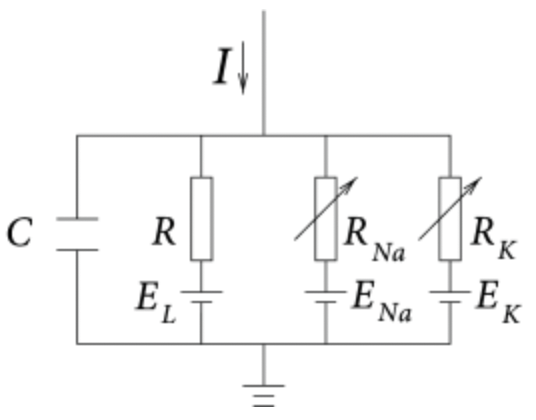

The hodgkins-huxley model was originally formulated in 1952 and ultimately won the 1963 Nobel Prize in Physiology or Medicine.

Hodgkins and Huxley probed a giant seq squid brain using some of the first [patch clamps](https://en.wikipedia.org/wiki/Patch_clamp) to collect empirical data for how a neuron spikes.

Based on their data and contemperary research on ion pumps and channels, they developed a model that effectively described how a neuron fires.

Their technique of combining empirical data with pre-existing knowledge to generate useful models might classify them as some of the first biophysicists. Similar techniques today are being used to understand [cellular aging](https://www.science.org/doi/10.1126/science.aax9552) by labs at UCSD for example.



## Quick review of circuit physics:

1. **Voltage** is a difference in electric potential. Positive charges want to move towards negative charges. Opposites attract. The voltage difference in each path of a parallel circuit is always the same.
2. **Batteries** create a specific voltage difference.
2. **Current** is the flow of electric charge from one place to another. It's measured in amps. In a parallel circuit the current of each branch does not split evenly and can be found by Ohm's law. Current scales with voltage and is slowed by resistance defined in **Ohm's Law**:
$$I = \frac{V}{R}$$
3. **Resistors** slow the current in a wire. In parallel they are combined by summing their inverses. You can think of this as a
$$\frac{1}{R_{sum}} = \sum \frac{1}{R}$$
4. **Capacitors** resists change in voltage and is defined by the following equation:
$$I = C\frac{dV}{dt}$$



## Neuron Cell Review

1. **Voltage spikes** are how neurons communicate signals to each other. The default potential of a neuron at rest is about -70 mV but it can spike up to +50mV once it reaches an activation potential of about -55mV. A spike is always followed by a short refractory period.
2. **Ion Channels** are proteins in the cell membrane that *passively* allow specific ions through. We particularly care about Na and K channels. There are certain channels that are non-specific and allow many types of ions to travel across the membrane.

Why might the ion channels be neccessary during a voltage spike?

3. **Ion Pumps** are proteins in the cell membrame that *actively* pump specific ions from one side to the other until they achieve a specific potential called the Nernst potential. I've included a table describing the relevant values:

| Ion Species | Nernst Potential (mV) | Description                                  |
|-------------|------------------------|----------------------------------------------|
| Na⁺ (Sodium) | +50                   | Drives inward current during depolarization. |
| K⁺ (Potassium) | -77                 | Drives outward current during repolarization.|
| Leak (mainly Cl⁻) | -54.387          | Represents background leakage currents.      |


4. **Cell Membrane** is a barrier between the inside and outside of the cell and helps maintain a voltage difference.

## Hodgkins-Huxley Model

Can we model real biological components using the circuit pieces we've learned about?

The Hodgkins-Huxley model represents a single neuron as a circuit.

1. It has an input current at the top that represents the charge received from the previous neuron.
2. Then it models each ion (Na, K, non-specific called Leak) as several circuits in parallel:
  1. Each circuit has a battery, corresponding to the ion pumps that activate when far away from a goal charge.
  2. Each circuit has a resistor, corresponding to the ion channels that passively allows charge to flow during an input spike in current. The resistance for Na and K is not constant as we'll see.
3. The cell membrane is modeled as a capacitor as it resists voltage change by seperating two distinct voltage counts.
4. Finally a battery at the bottom sets a default voltage potential that our circuit will maintain when there is no net flux.


To better understand what's going on let's consider just the current going through the Na circuit.

$$ I_{Na} = \frac{1}{R_{Na}}(V-E_{Na})  $$
Ohm's law says the current is equal to Resistance * Voltage. We know resistors in parallel take the inverse of their resistance and we simply add the voltage of the overall circuit and the voltage difference from the Na battery. ($E_{Na}$ is pointing the opposite direction of the flow of the circuit so we subtract it.)

Then the total current is:
$$ I(t)= C\frac{dV}{dt} +  I_{Na} + I_{K} + I_{L} $$
substituting our previous result and letting $\overline{E}$ be the average charge of all batteries we see
$$ I(t)= C\frac{dV}{dt} +  \frac{1}{R}(V-\overline{E})$$
In this model $C$, $V$, $\overline{E}$ are constants and it's clear that this form will not produce the spike shape we are looking for.

Therefore Hodgkin and Huxley decided to model the resistance of each circuit using the following equations based on their patch-clamp measurements of a giant squid neuron.

$$ I_{Na}   = \bar{g}_{Na} m^3 h (V-E_{Na})$$
$$I_{K}   = \bar{g}_{K} n^4 (V-E_{K})$$
$$I_{L}   = \bar{g}_{L} (V-E_{L})$$

They developed 3 variables $n$, $m$, and $h$ that vary with charge but don't change automatically.

- m is associated with the activation of Na channels
- h is associated with the inactivation of Na channels
- n is associated with the activation of K channels

Pay particular note to the $\tau$ variables which model how fast each variable can change as a function of voltage.

Which variable do you expect to be the slowest to update at low voltages.

---
To implement the HH model, you will need to implement the equations to model the Sodium, Potassium, and Leak currents:

All the equations necessary to model the Sodium current:

\begin{align}
  I_{Na}   &= \bar{g}_{Na} m^3 h (V-E_{Na})\\
  \alpha_m &= 0.1 \frac{V+40}{1-e^{-\frac{V+40}{10}}} \\
  \beta_m  &= 4 e^{-\frac{V+65}{18}} \\
  \tau_m &= \frac{1}{\alpha_m(V) + \beta_m(V)} \\
  m_0 &= \frac{\alpha_m(V)}{\alpha_m(V) + \beta_m(V)}\\
  \frac{dm}{dt} &= -\frac{1}{\tau_m (V)}[m-m_0(V)] \\
  \alpha_h &= 0.07 e^{-\frac{V+65}{20}} \\
  \beta_h  &= \frac{1}{1+e^{-\frac{V+35}{10}}} \\
  \tau_h &= \frac{1}{\alpha_h(V) + \beta_h(V)} \\
  h_0 &= \frac{\alpha_h(V)}{\alpha_h(V) + \beta_h(V)}\\
  \frac{dh}{dt} &= -\frac{1}{\tau_h (V)}[h-h_0(V)] \\
\end{align}

All the equations necessary to model the Potassium current:
\begin{align}
  I_{K}   &= \bar{g}_{K} n^4 (V-E_{K})\\
  \alpha_n &= 0.01 \frac{V+55}{1-e^{-\frac{V+55}{10}}} \\
  \beta_n  &= 0.125 e^{-\frac{V+65}{80}}\\
  \tau_n &= \frac{1}{\alpha_n(V) + \beta_n(V)} \\
  n_0 &= \frac{\alpha_n(V)}{\alpha_n(V) + \beta_n(V)}\\
  \frac{dn}{dt} &= -\frac{1}{\tau_n (V)}[n-n_0(V)] \\
\end{align}

All the equations to model the Leak current:
\begin{align}
  I_{L}   &= \bar{g}_{L} (V-E_{L})\\
\end{align}

Finally, the equation to model the change in the membrane potential due to some injected current $I_{inj}$:
$$ \frac{dV}{dt} = (I_{inj}(t) - I_{Na} - I_K - I_L)/ C_m $$


Let's implement a few the missing functions below ourselves.



In [ ]:
# IMPORT STATEMENTS
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import odeint
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [ ]:
def HHModel(y, t, I):
    V = y[0]
    m = y[1]
    n = y[2]
    h = y[3]

    # computing the injected current for the present timestep.
    # I[0] is the amplitude of the current
    # I[1] start time of input current pulse
    # I[2] end time of input current pulse
    Iinj = I[0]*(t>I[1]) - I[0]*(t>I[2])

    # Constants
    C_m  =   1.0 # membrane capacitance, in uF/cm^2
    g_Na = 120.0 # maximum conductances, in mS/cm^2
    g_K  =  36.0
    g_L  =   0.3
    E_Na =  50.0 # Nernst reversal potentials, in mV
    E_K  = -77.0
    E_L  = -54.387

    # Compute alpha and beta functions
    alpha_m = 0.1*(V+40.0)/(1.0-np.exp(-(V+40.0)/10.0))
    beta_m  = 4.0*np.exp(-(V+65.0)/18.0)
    alpha_h = 0.07*np.exp(-(V+65.0)/20.0)
    beta_h  = 1.0/(1.0+np.exp(-(V+35.0)/10.0))
    alpha_n = 0.01*(V+55.0)/(1.0-np.exp(-(V+55.0)/10.0))
    beta_n  = 0.125*np.exp(-(V+65)/80.0)

    # TODO Compute membrane currents
    I_Na =
    I_K  =
    I_L  =
    I_ion =

    # TODO Compute time constants and steady-state values
    tau_m =
    m_inf =
    tau_h =
    h_inf =
    tau_n =
    n_inf =

    # Compute derivatives
    dVdt =
    dmdt =
    dhdt =
    dndt =

    return np.array([dVdt, dmdt, dndt, dhdt])


Now let's try running the model!

These are some simple default `initial` values for a short current impulse. If you'd like, try and modify the code to show a continues input current.

You can also see how are model changes if we choose a different starting voltage, V.

In [ ]:
T_total = 500 # ms
t = np.linspace(0, T_total, T_total+1)

# Set external current amplitudes
I_current_amplitude = [0, 6, 10.7, 20] # microA/cm^2

t_current_start = 50 # input current pulse will start at this time
t_current_end   = [52, 70] # input current pulse will end at this time

# Set the initial values for V, m, n, h
initial = [-63, 0.0530, 0.31777, 0.5961]

# initialize empty array
Iapp = np.zeros_like(t)

# Solve the differential equation using odeint
# t_idx is the index of t_current_end, t0 is the value
# i.e t_idx = 0,1 and t0 = endpoint1,endpoint2
for t_idx, t_end in enumerate(t_current_end):
    V = []
    m = []
    n = []
    h = []
    for i_idx, i0 in enumerate(I_current_amplitude):  # loop over different amplitudes
        Iinput = [i0,t_current_start,t_end]
        # Solve the differential equation using odeint

        y = odeint(HHModel, initial, t, args=(Iinput,)) # integrate the values over time
        V.append(y[:,0]) # access all of the values for V
        m.append(y[:,1])
        h.append(y[:,2])
        n.append(y[:,3])

    # m represents the activation of the sodium (Na+) channels.
    # n represents the activation of the potassium (K+) channels.
    # h represents the inactivation of the sodium (Na+) channels.

        # This is to visualize the stimulus
        for i in range(T_total):
            if (i>= t_current_start) and (i<=t_current_end[t_idx]):
                Iapp[i] = I_current_amplitude[i_idx]
            else:
                Iapp[i] = 0

        # TODO: Plot V(t)
        plt.figure()
        plt.plot(t, V[i_idx])

        #TODO: Overlay with the stimulus
        plt.plot(t, Iapp)

        plt.ylabel('Voltage (mV)', fontsize=15)
        plt.xlabel('Time t (ms)', fontsize=15)
        plt.title('Input Current = {} (\u00B5A/cm\u00B2)'.format(i0), fontweight='bold', fontsize=14)

        plt.show()



Finally let's take a look at how n, m, and h vary with voltage a bit more closely.

In [ ]:
# Define voltage range
V = np.linspace(-100, 50, 500)

# Compute alpha and beta functions
alpha_m = 0.1*(V+40.0)/(1.0 - np.exp(-(V+40.0)/10.0))
beta_m = 4.0*np.exp(-(V+65.0)/18.0)
alpha_h = 0.07*np.exp(-(V+65.0)/20.0)
beta_h = 1.0/(1.0 + np.exp(-(V+35.0)/10.0))
alpha_n = 0.01*(V+55.0)/(1.0 - np.exp(-(V+55.0)/10.0))
beta_n = 0.125*np.exp(-(V+65)/80.0)

# You can copy these from above
tau_m =
m_inf =
tau_h =
h_inf =
tau_n =
n_inf =

In [ ]:
plt.figure()
plt.plot(V, m_inf, label='m_inf')
plt.plot(V, h_inf, label='h_inf')
plt.plot(V, n_inf, label='n_inf')
plt.axvline(x=0, color='black', linestyle='--', label='V=0 mV')
plt.title('Steady-State Values vs Voltage')
plt.xlabel('Membrane Voltage (mV)')
plt.ylabel('Steady-State Value')
plt.legend()
plt.grid(True)

plt.show()

- Why is h much higher at lower voltages?
- Which becomes higher at lower voltages, m or n? Why does that make sense?

In [ ]:
# Plot time constants
plt.figure()
plt.plot(V, tau_m, label='tau_m')
plt.plot(V, tau_h, label='tau_h')
plt.plot(V, tau_n, label='tau_n')
plt.axvline(x=0, color='black', linestyle='--', label='V=0 mV')
plt.title('Time Constants vs Voltage')
plt.xlabel('Membrane Voltage (mV)')
plt.ylabel('Time Constant (ms)')
plt.legend()
plt.grid(True)
plt.show()

Remember here a lower tau corresponds to a faster update time.

### Bonus fact

The shape of a neuron spike is not consistent. It varies between neurons and recent research indicates that it might vary within a single neuron too. Lots of active research happening in this field. (Voytek Lab at UCSD and many others)